# Visualisation — Selection du meilleur modele d'embedding et du k optimal

Ce notebook charge les resultats de `select_best_embedding_and_k.py`
(`results.json`) et visualise :

1. Les courbes **Recall@k** par modele.
2. Le **MRR** (Mean Reciprocal Rank) par modele.
3. Le tableau **k minimal pour atteindre un seuil de rappel** donne.
4. Une heatmap recapitulative Recall@k (modele x k).
5. La mise en evidence du **meilleur couple (modele, k)**.


In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd

# Chemin vers le fichier de resultats produit par select_best_embedding_and_k.py
RESULTS_PATH = "results.json"

if not Path(RESULTS_PATH).exists():
    raise FileNotFoundError(
        f"'{RESULTS_PATH}' introuvable. Placez le fichier json genere par "
        f"select_best_embedding_and_k.py a cote de ce notebook, ou modifiez "
        f"RESULTS_PATH ci-dessus."
    )

with open(RESULTS_PATH, "r", encoding="utf-8") as f:
    data = json.load(f)

k_list = data["k_list"]
n_gold = data["n_gold_queries"]
results = data["results"]
best = data["best_model_k"]

print(f"Requetes evaluees (attributs avec label reel) : {n_gold}")
print(f"Modeles compares : {len(results)}")
print(f"Valeurs de k testees : {k_list}")


Requetes evaluees (attributs avec label reel) : 85
Modeles compares : 5
Valeurs de k testees : [1, 3, 5, 10, 15, 20, 30]


## 1. Tableau recapitulatif (Recall@k + MRR)

In [13]:
rows = []
for r in results:
    row = {"model": r["model"]}
    for k in k_list:
        row[f"R@{k}"] = r["recall_at_k"][str(k)]
    row["MRR"] = r["mrr"]
    rows.append(row)

df = pd.DataFrame(rows).set_index("model").sort_values(f"R@{max(k_list)}", ascending=False)
df_display = df.style.format({c: "{:.3f}" for c in df.columns if c != "fallback"}) \
                       .background_gradient(cmap="Greens", subset=[c for c in df.columns if c.startswith("R@") or c == "MRR"])
df.to_csv("embedding_results.csv", index=True)
df_display



,R@1,R@3,R@5,R@10,R@15,R@20,R@30,MRR
model,,,,,,,,
sentence-transformers/all-MiniLM-L6-v2,0.188,0.400,0.471,0.659,0.729,0.824,0.871,0.340
BAAI/bge-small-en-v1.5,0.165,0.306,0.435,0.682,0.765,0.812,0.847,0.307
intfloat/e5-small-v2,0.200,0.388,0.506,0.659,0.659,0.718,0.776,0.336
sentence-transformers/LaBSE,0.094,0.212,0.318,0.412,0.506,0.588,0.671,0.193
dmis-lab/biobert-base-cased-v1.2,0.035,0.082,0.094,0.224,0.271,0.329,0.423,0.083


## 2. Courbes Recall@k par modele

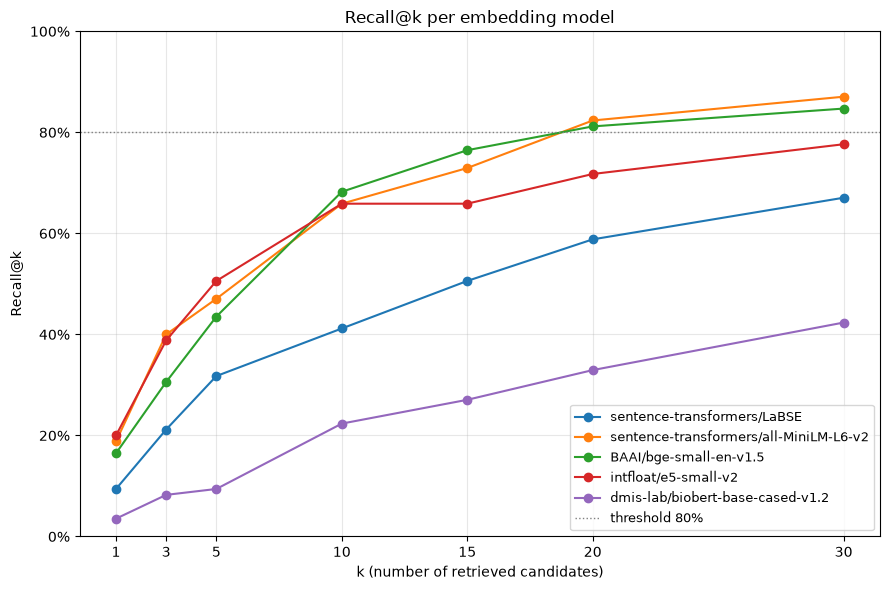

In [5]:
fig, ax = plt.subplots(figsize=(9, 6))

for r in results:
    y = [r["recall_at_k"][str(k)] for k in k_list]
    style = "--" if r["is_fallback"] else "-"
    ax.plot(k_list, y, marker="o", linestyle=style, label=r["model"])

ax.axhline(0.8, color="grey", linestyle=":", linewidth=1, label="threshold 80%")
ax.set_xlabel("k (number of retrieved candidates)")
ax.set_ylabel("Recall@k")
ax.set_title("Recall@k per embedding model")
ax.set_ylim(0, 1)
ax.set_xticks(k_list)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.legend(loc="lower right", fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("recall_at_k_plot.png", dpi=300)
plt.show()


## 3. MRR par modele

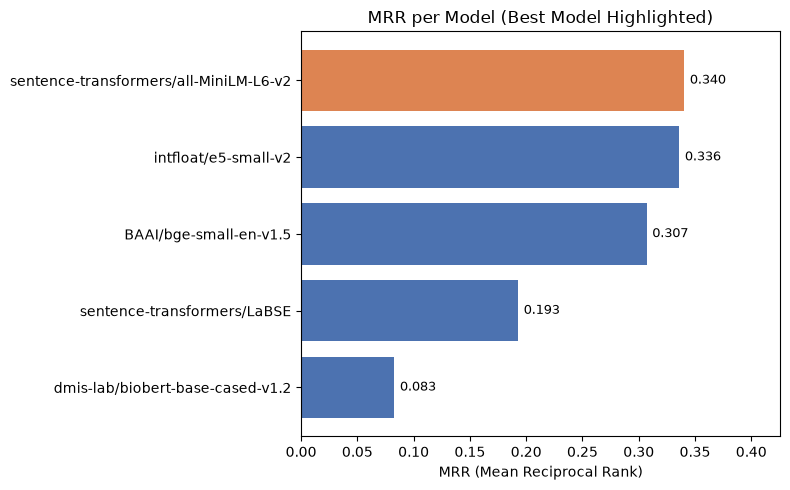

In [7]:
mrr_series = pd.Series({r["model"]: r["mrr"] for r in results}).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
colors = ["#4C72B0" if m != best["model"] else "#DD8452" for m in mrr_series.index]
ax.barh(mrr_series.index, mrr_series.values, color=colors)
for i, v in enumerate(mrr_series.values):
    ax.text(v + 0.005, i, f"{v:.3f}", va="center", fontsize=9)
ax.set_xlabel("MRR (Mean Reciprocal Rank)")
ax.set_title("MRR per Model (Best Model Highlighted)")
ax.set_xlim(0, max(mrr_series.values) * 1.25)
plt.tight_layout()
plt.savefig("mrr_plot.png", dpi=300)
plt.show()


## 4. Heatmap Recall@k (modele x k)

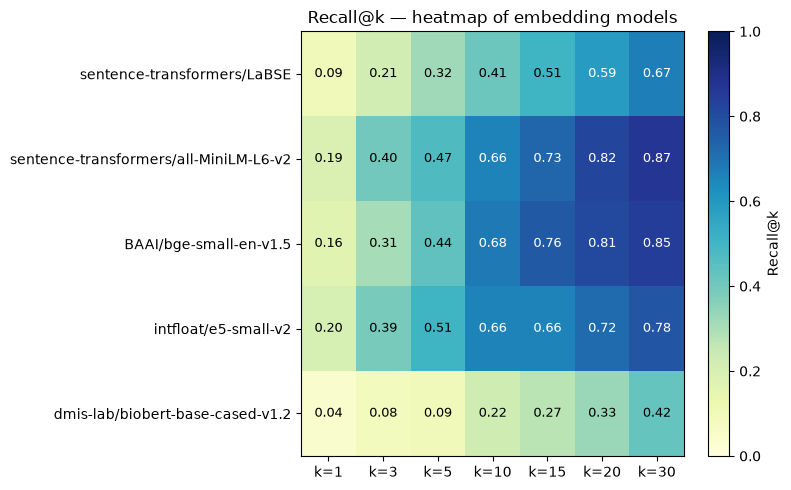

In [8]:
heat = pd.DataFrame(
    {k: [r["recall_at_k"][str(k)] for r in results] for k in k_list},
    index=[r["model"] for r in results],
)

fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(heat.values, cmap="YlGnBu", aspect="auto", vmin=0, vmax=1)

ax.set_xticks(range(len(k_list)))
ax.set_xticklabels([f"k={k}" for k in k_list])
ax.set_yticks(range(len(heat.index)))
ax.set_yticklabels(heat.index)

for i in range(heat.shape[0]):
    for j in range(heat.shape[1]):
        val = heat.values[i, j]
        ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                color="white" if val > 0.55 else "black", fontsize=9)

ax.set_title("Recall@k — heatmap of embedding models")
fig.colorbar(im, ax=ax, label="Recall@k")
plt.tight_layout()
plt.savefig("recall_at_k_heatmap.png", dpi=300)
plt.show()


## 5. k minimal pour atteindre un seuil de rappel donne

In [10]:
thr_rows = []
for r in results:
    row = {"model": r["model"]}
    for th, k in r["min_k_for_recall_threshold"].items():
        row[f"R>={float(th)*100:.0f}%"] = k if k is not None else "—"
    thr_rows.append(row)

thr_df = pd.DataFrame(thr_rows).set_index("model")
thr_df.to_csv("recall_thresholds.csv", index=True)
thr_df


,R>=50%,R>=60%,R>=70%,R>=80%,R>=90%
model,,,,,
sentence-transformers/LaBSE,15,30,—,—,—
sentence-transformers/all-MiniLM-L6-v2,10,10,15,20,—
BAAI/bge-small-en-v1.5,10,10,15,20,—
intfloat/e5-small-v2,5,10,20,—,—
dmis-lab/biobert-base-cased-v1.2,—,—,—,—,—


## 6. Meilleur couple (modele, k)

Meilleur couple (modele, k) selon le script :
  Modele : sentence-transformers/all-MiniLM-L6-v2
  k      : 30
  Recall : 0.8706
  Fallback local : False


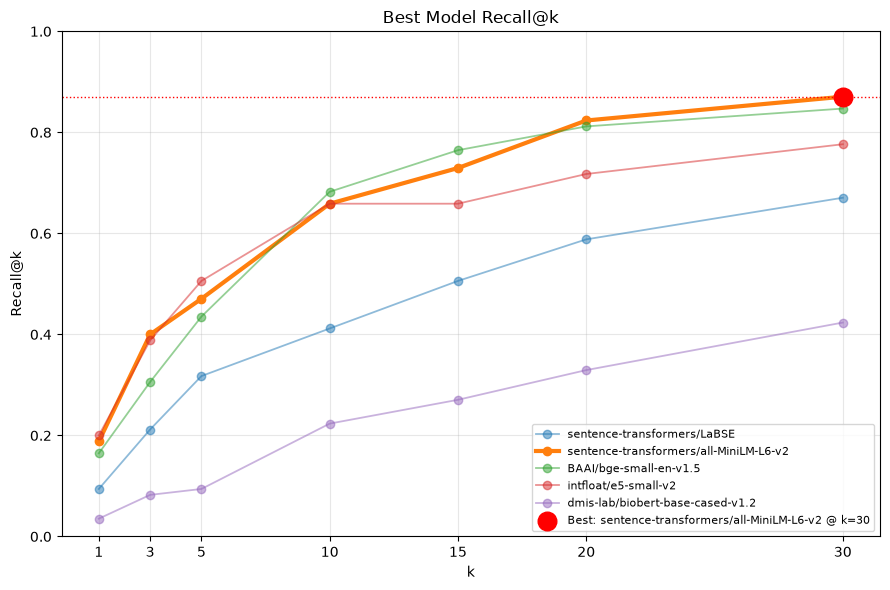

In [11]:
print("Meilleur couple (modele, k) selon le script :")
print(f"  Modele : {best['model']}")
print(f"  k      : {best['k']}")
print(f"  Recall : {best['recall']:.4f}")
print(f"  Fallback local : {best['is_fallback']}")

fig, ax = plt.subplots(figsize=(9, 6))
for r in results:
    y = [r["recall_at_k"][str(k)] for k in k_list]
    lw = 3 if r["model"] == best["model"] else 1.3
    alpha = 1.0 if r["model"] == best["model"] else 0.5
    ax.plot(k_list, y, marker="o", linewidth=lw, alpha=alpha, label=r["model"])

ax.scatter([best["k"]], [best["recall"]], s=180, color="red", zorder=5,
           label=f"Best: {best['model']} @ k={best['k']}")
ax.axhline(best["recall"], color="red", linestyle=":", linewidth=1)
ax.set_xlabel("k")
ax.set_ylabel("Recall@k")
ax.set_title("Best Model Recall@k")
ax.set_ylim(0, 1)
ax.set_xticks(k_list)
ax.legend(loc="lower right", fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("best_model_k_plot.png", dpi=300)
plt.show()


## Lecture des resultats

- **`sentence-transformers/all-MiniLM-L6-v2`** et **`BAAI/bge-small-en-v1.5`**
  dominent nettement les autres modeles a partir de k=10 (Recall@10 ~0.66-0.68).
- **`intfloat/e5-small-v2`** est le meilleur a k tres bas (Recall@1 = 0.20,
  le plus eleve du lot) — interessant si le budget de candidats est tres
  contraint (k=1 ou k=3).
- **`dmis-lab/biobert-base-cased-v1.2`** est nettement en retrait sur cette
  tache : BioBERT est optimise pour la comprehension biomedicale
  (litterature, notes cliniques), pas pour la similarite de description de
  schema court (nom de colonne + phrase descriptive), d'ou son MRR tres
  faible (0.083).
- **LaBSE** (multilingue) est correct mais moins precis que les modeles
  anglais specialises en similarite de phrase courte (MiniLM, BGE, E5),
  ce qui est attendu : sa force est le cross-lingue, pas la finesse
  semantique sur du texte technique anglais.
- Aucun modele n'atteint 90% de rappel meme a k=30 : cela confirme qu'un
  post-filtrage (LLM ou regles) reste necessaire apres le retrieval pour
  affiner le choix final parmi les k candidats retrouves.
